In [5]:
# ==========================================
# 0. Setup and Imports
# ==========================================
import sys
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Add 'src' directory to system path for custom module import
sys.path.append(os.path.abspath("../src"))
from utils import get_summary_stats, get_category_summary

# Ensure output directory exists
os.makedirs("../data/processed", exist_ok=True)

In [6]:
# ==========================================
# 1. NumPy Operations & Vectorization Comparison
# ==========================================

# 1.1 Array creation and elementwise operations
arr = np.array([10, 20, 30, 40, 50])
print("Original Array:", arr)
print("Elementwise Addition (+5):", arr + 5)
print("Elementwise Multiplication (*2):", arr * 2)
print("Elementwise Exponentiation (**2):", arr ** 2)

# 1.2 Loop vs. Vectorized Execution Benchmark
n_elements = 1_000_000
python_list = list(range(n_elements))
numpy_array = np.arange(n_elements)

# Time Python for-loop
start_time = time.time()
loop_result = [x * 2 for x in python_list]
loop_time = time.time() - start_time

# Time NumPy vectorized operation
start_time = time.time()
vectorized_result = numpy_array * 2
vectorized_time = time.time() - start_time

# Display benchmark results
print("\n--- Performance Comparison (1,000,000 Elements) ---")
print(f"Python Loop Time:     {loop_time:.6f} seconds")
print(f"NumPy Vectorized Time:{vectorized_time:.6f} seconds")
print(f"Speedup: NumPy is ~{loop_time / vectorized_time:.1f}x faster.")

Original Array: [10 20 30 40 50]
Elementwise Addition (+5): [15 25 35 45 55]
Elementwise Multiplication (*2): [ 20  40  60  80 100]
Elementwise Exponentiation (**2): [ 100  400  900 1600 2500]

--- Performance Comparison (1,000,000 Elements) ---
Python Loop Time:     0.042831 seconds
NumPy Vectorized Time:0.001994 seconds
Speedup: NumPy is ~21.5x faster.


In [7]:
# ==========================================
# 2. Dataset Loading & Inspection
# ==========================================
data_path = "../data/raw/starter_data.csv"
df = pd.read_csv(data_path)

print("--- DataFrame Information ---")
df.info()

print("\n--- First 5 Rows ---")
display(df.head())

--- DataFrame Information ---
<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   category  10 non-null     str  
 1   value     10 non-null     int64
 2   date      10 non-null     str  
dtypes: int64(1), str(2)
memory usage: 372.0 bytes

--- First 5 Rows ---


,category,value,date
0,A,10,2025-08-01
1,B,15,2025-08-02
2,A,12,2025-08-03
3,B,18,2025-08-04
4,C,25,2025-08-05


In [8]:
# ==========================================
# 3 & 5. Summary Statistics & Reusable Functions
# ==========================================

# 3.1 Calculate describe() using imported utility function
numeric_summary = get_summary_stats(df)
print("--- Descriptive Statistics for Numeric Columns ---")
display(numeric_summary)

# 3.2 Perform groupby aggregation using imported utility function
category_summary = get_category_summary(df, group_col="category", val_col="value")
print("\n--- Groupby Aggregation by Category ---")
display(category_summary)

--- Descriptive Statistics for Numeric Columns ---


,value
count,10.000000
mean,17.600000
std,7.381659
min,10.000000
25%,12.250000
50%,14.500000
75%,23.250000
max,30.000000



--- Groupby Aggregation by Category ---


,category,count,mean,sum,std
0,A,4,11.500000,46,1.290994
1,B,3,15.666667,47,2.081666
2,C,3,27.666667,83,2.516611


In [9]:
# ==========================================
# 4. Save Outputs
# ==========================================
output_csv_path = "../data/processed/summary.csv"
category_summary.to_csv(output_csv_path, index=False)

print(f"Summary table successfully saved to: {output_csv_path}")

Summary table successfully saved to: ../data/processed/summary.csv


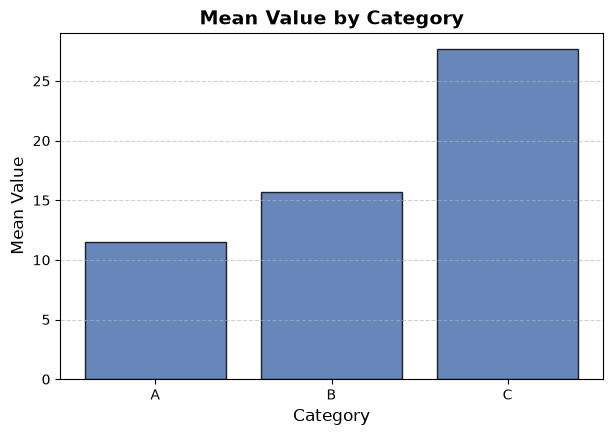

Plot successfully saved to: ../data/processed/summary_plot.png


In [10]:
# ==========================================
# Bonus: Visualization and Export
# ==========================================
plt.figure(figsize=(7, 4.5))

# Plot category mean values
plt.bar(
    category_summary["category"], 
    category_summary["mean"], 
    color="#4C72B0", 
    edgecolor="black", 
    alpha=0.85
)

# Chart styling
plt.title("Mean Value by Category", fontsize=14, fontweight="bold")
plt.xlabel("Category", fontsize=12)
plt.ylabel("Mean Value", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.6)

# Save plot to processed directory
plot_output_path = "../data/processed/summary_plot.png"
plt.savefig(plot_output_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Plot successfully saved to: {plot_output_path}")